<a href="https://colab.research.google.com/github/Leottero/Challenge_DataScience_AluraStore/blob/main/TelecomX_Analysis_Consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Análisis de Churn - Challenge Telecom X
Este notebook contiene el flujo completo de ETL y Análisis Exploratorio de Datos (EDA) para el proyecto Telecom X.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

## 1. Extracción y Limpieza (ETL)

In [2]:
response = requests.get(DATA_URL)
df_raw = pd.DataFrame(response.json())

# Aplanamiento
df = pd.concat([
    df_raw[['customerID', 'Churn']],
    pd.json_normalize(df_raw['customer']),
    pd.json_normalize(df_raw['phone']),
    pd.json_normalize(df_raw['internet']),
    pd.json_normalize(df_raw['account'])
], axis=1)

# Limpieza
df = df.replace(r'^\s*$', pd.NA, regex=True)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')
df['Cuentas_Diarias'] = (df['Charges.Monthly'] / 30).round(2)

# Estandarización
binary_map = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}
cols_to_map = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
for col in cols_to_map:
    if col in df.columns:
        df[col] = df[col].map(binary_map).fillna(df[col])

# Traducción
df = df.rename(columns={
    'customerID': 'ID_Cliente', 'Churn': 'Abandono', 'gender': 'Genero', 'SeniorCitizen': 'Adulto_Mayor', 'Partner': 'Socio',
    'Dependents': 'Dependientes', 'tenure': 'Meses_Permanencia', 'PhoneService': 'Servicio_Telefonico', 'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet', 'OnlineSecurity': 'Seguridad_Online', 'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo', 'TechSupport': 'Soporte_Tecnico', 'StreamingTV': 'TV_Streaming',
    'StreamingMovies': 'Peliculas_Streaming', 'Contract': 'Contrato', 'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago', 'Charges.Monthly': 'Cargos_Mensuales', 'Charges.Total': 'Cargos_Totales'
})

df.head()

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


## 2. Análisis Estadístico

In [3]:
print(df.describe().transpose())
print(f"\nTasa de Abandono Total: {df['Abandono'].mean():.2%}")

                          count         mean          std    min      25%  \
Adulto_Mayor             7267.0     0.162653     0.369074   0.00    0.000   
Socio                    7267.0     0.484106     0.499782   0.00    0.000   
Dependientes             7267.0     0.300124     0.458343   0.00    0.000   
Meses_Permanencia        7267.0    32.346498    24.571773   0.00    9.000   
Servicio_Telefonico      7267.0     0.902711     0.296371   0.00    1.000   
Seguridad_Online         7267.0     0.285950     0.451897   0.00    0.000   
Respaldo_Online          7267.0     0.344571     0.475261   0.00    0.000   
Proteccion_Dispositivo   7267.0     0.342782     0.474672   0.00    0.000   
Soporte_Tecnico          7267.0     0.289528     0.453575   0.00    0.000   
TV_Streaming             7267.0     0.383927     0.486374   0.00    0.000   
Peliculas_Streaming      7267.0     0.387505     0.487214   0.00    0.000   
Facturacion_Electronica  7267.0     0.593230     0.491265   0.00    0.000   

## 3. Visualizaciones

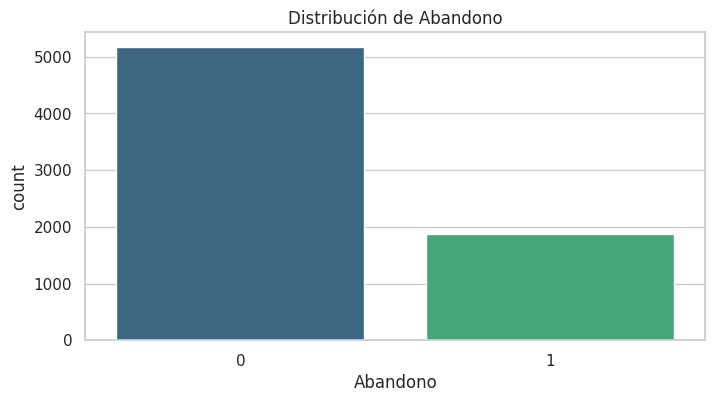

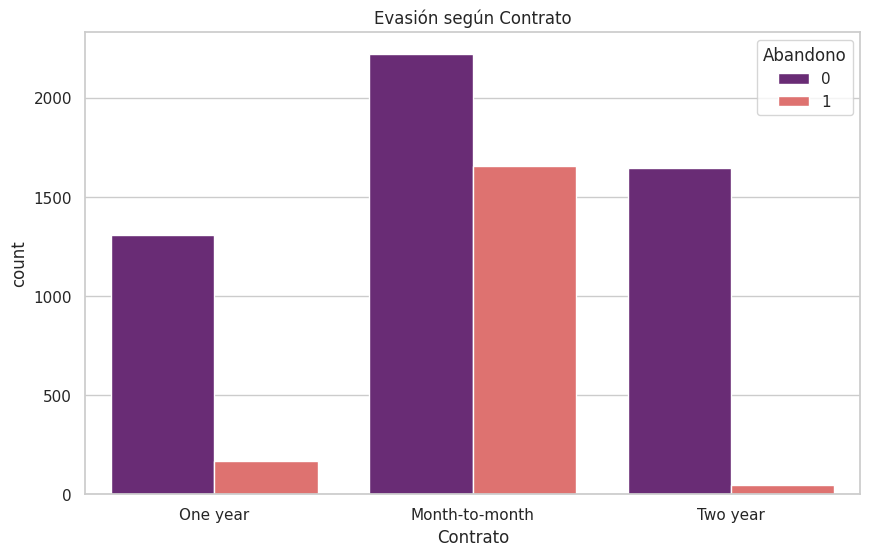

In [5]:
sns.set_theme(style="whitegrid")

# Create a copy of the dataframe and handle NA values in 'Abandono' for plotting
df_plot = df.copy()
df_plot = df_plot.dropna(subset=['Abandono']) # Drop rows where 'Abandono' is NA
df_plot['Abandono'] = df_plot['Abandono'].astype(int) # Convert 'Abandono' to integer type

plt.figure(figsize=(8, 4))
sns.countplot(data=df_plot, x='Abandono', hue='Abandono', palette='viridis', legend=False)
plt.title('Distribución de Abandono')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df_plot, x='Contrato', hue='Abandono', palette='magma')
plt.title('Evasión según Contrato')
plt.show()